# HCSumm* / Proposed Dual-Feature Call Graph Summarization

Notebook ini menjalankan pipeline dari **file `.py`** sebagai input:

1. Baca dua file Python: `t0` dan `t1`
2. Ekstrak directed call graph
3. Visualisasi call graph dengan Graphviz
4. Ekstrak execution path
5. Hitung fitur perilaku `f(v)`
6. Bangun directed node2vec random walk dengan outgoing edge
7. Latih Word2Vec untuk mendapatkan embedding `e(v)`
8. Normalisasi `f(v)` dan `e(v)`
9. Fusion menjadi `x(v) = [e'(v) || f'(v)]`
10. Hitung Euclidean distance
11. Ward clustering
12. Bangun summary graph

Catatan: random walk node2vec di notebook ini dibuat sendiri agar **arah edge tetap dipertahankan**.

In [813]:
# Kalau dijalankan di environment baru, aktifkan cell ini.
# Di Google Colab / Jupyter, hapus tanda komentar jika package belum tersedia.

!pip install networkx numpy scipy scikit-learn pandas graphviz pydot gensim

In [814]:
!{sys.executable} -m pip install scipy

zsh:1: parse error near `-m'


In [815]:
import ast
import os
import random
import numpy as np
import pandas as pd
import networkx as nx

from IPython.display import display, Image
from graphviz import Digraph

# from sklearn.preprocessing import normalize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

try:
    from gensim.models import Word2Vec
except Exception as e:
    print("Gensim belum tersedia atau bermasalah. Jalankan: pip install gensim")
    raise e

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Library loaded.")

Library loaded.


## 1. Set path file program t0 dan t1

Ganti `FILE_T0` dan `FILE_T1` sesuai lokasi file `.py` yang ingin dibandingkan.

In [ ]:
# =========================
# GANTI PATH FILE DI SINI
# =========================

FILE_T0 = '/Users/lanaginting/Documents/p2mi/tc3_t0.py'
FILE_T1 = '/Users/lanaginting/Documents/p2mi/tc3_t1.py'

# Jumlah cluster untuk dry run / synthetic scenario
K_CLUSTERS = 3

# Parameter directed node2vec
EMBED_DIM = 4
WALK_LENGTH = 10
NUM_WALKS = 200
P_RETURN = 1.0
Q_INOUT = 1.0

print("FILE_T0:", FILE_T0)
print("FILE_T1:", FILE_T1)

FILE_T0: /Users/lanaginting/Documents/p2mi/tc3-2_t0.py
FILE_T1: /Users/lanaginting/Documents/p2mi/tc3-2_t1.py


## 2. Fungsi ekstraksi directed call graph dari file `.py`

Extractor ini membaca AST Python dan membangun `nx.DiGraph`.
Node = fungsi/method, edge = relasi pemanggilan fungsi.

Untuk menjaga graf tetap bersih, edge hanya ditambahkan jika callee merupakan fungsi yang didefinisikan di file yang sama.

In [817]:
class CallGraphExtractor(ast.NodeVisitor):
    def __init__(self):
        self.graph = nx.DiGraph()
        self.current_function = None
        self.defined_functions = set()

    def visit_FunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

    def visit_AsyncFunctionDef(self, node):
        self.defined_functions.add(node.name)
        self.graph.add_node(node.name)
        self.generic_visit(node)

def _get_callee_name(call_node):
    if isinstance(call_node.func, ast.Name):
        return call_node.func.id
    if isinstance(call_node.func, ast.Attribute):
        return call_node.func.attr
    return None

class CallEdgeExtractor(ast.NodeVisitor):
    def __init__(self, graph, defined_functions):
        self.graph = graph
        self.defined_functions = defined_functions
        self.current_function = None

    def visit_FunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_AsyncFunctionDef(self, node):
        prev = self.current_function
        self.current_function = node.name
        self.generic_visit(node)
        self.current_function = prev

    def visit_Call(self, node):
        callee = _get_callee_name(node)
        if self.current_function and callee in self.defined_functions:
            self.graph.add_edge(self.current_function, callee)
        self.generic_visit(node)

def extract_call_graph_from_py(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        source = f.read()

    tree = ast.parse(source)

    node_extractor = CallGraphExtractor()
    node_extractor.visit(tree)

    edge_extractor = CallEdgeExtractor(node_extractor.graph, node_extractor.defined_functions)
    edge_extractor.visit(tree)

    return node_extractor.graph, source

print("Call graph extractor ready.")

Call graph extractor ready.


## 3. Fungsi visualisasi call graph dengan Graphviz

In [818]:
def graph_to_graphviz(G, title="Call Graph"):
    dot = Digraph(comment=title)
    dot.attr(rankdir="LR")
    dot.attr("node", shape="circle", style="filled", fillcolor="lightblue", fontname="Arial")

    for n in G.nodes():
        dot.node(str(n), str(n))

    for u, v in G.edges():
        dot.edge(str(u), str(v))

    return dot

### [TAMBAHAN VISUALISASI] ---

def graph_to_graphviz_with_clusters(G, node_to_cluster, clusters, title="Call Graph with Clusters"):
    dot = Digraph(comment=title)
    dot.attr(rankdir="TB")
    dot.attr("node", shape="circle", style="filled", fontname="Arial", fontsize="10")
    
    # Define a color palette for clusters
    colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A", "#98D8C8", "#F7DC6F", "#BB8FCE", "#85C1E2"]
    
    # Create subgraphs for each cluster
    for cid, members in sorted(clusters.items()):
        color = colors[(cid - 1) % len(colors)]
        
        with dot.subgraph(name=f"cluster_{cid}") as subgraph:
            subgraph.attr(label=f"Cluster {cid}", style="filled", color=color, fillcolor=color, alpha="0.2")
            subgraph.attr("node", fillcolor=color, fontcolor="black")
            
            for node in members:
                subgraph.node(str(node), str(node))
    
    # Add edges from original graph
    for u, v in G.edges():
        dot.edge(str(u), str(v))
    
    return dot

### ---

def show_graph(G, filename, title="Call Graph"):
    dot = graph_to_graphviz(G, title)
    out_path = dot.render(filename, format="png", cleanup=True)
    display(Image(filename=out_path))
    return out_path

### [TAMBAHAN VISUALISASI] ---

def show_graph_with_clusters(G, node_to_cluster, clusters, filename, title="Call Graph with Clusters"):
    dot = graph_to_graphviz_with_clusters(G, node_to_cluster, clusters, title)
    out_path = dot.render(filename, format="png", cleanup=True)
    display(Image(filename=out_path))
    return out_path

### ---

print("Graphviz helpers ready.")

Graphviz helpers ready.


## 4. Baca file t0 dan t1, ekstrak call graph, dan visualisasikan

In [819]:
G_t0, source_t0 = extract_call_graph_from_py(FILE_T0)
G_t1, source_t1 = extract_call_graph_from_py(FILE_T1)

print("=== SOURCE t0 ===")
print(source_t0)
print("\n=== SOURCE t1 ===")
print(source_t1)

print("\n=== CALL GRAPH t0 ===")
print("Nodes:", list(G_t0.nodes()))
print("Edges:", list(G_t0.edges()))

print("\n=== CALL GRAPH t1 ===")
print("Nodes:", list(G_t1.nodes()))
print("Edges:", list(G_t1.edges()))

=== SOURCE t0 ===
# TC3-2: Add New Exit Node (t0) - Baseline Organic
# Total Node: ±80

def main():
    gateway_entry()

def gateway_entry():
    validate_request(); parse_payload(); auth_check()
    workflow_manager()

def validate_request():
    check_header(); check_body(); check_version()
def check_header(): pass
def check_body(): pass
def check_version(): pass

def parse_payload():
    sanitize_input(); map_to_dto()
def sanitize_input():
    trim_space(); escape_sql(); strip_html(); remove_nulls()
def trim_space(): pass
def escape_sql(): pass
def strip_html(): pass
def remove_nulls(): pass
def map_to_dto(): pass

def auth_check():
    get_token(); verify_signature(); check_expiry()
def get_token(): pass
def verify_signature(): pass
def check_expiry(): pass

def workflow_manager():
    # Jalur utama yang dalam
    prepare_context()
    execute_business_logic()

def prepare_context():
    load_user_profile(); fetch_global_settings(); init_cache()
def load_user_profile(): pass
def fe

Visualisasi Call Graph t0


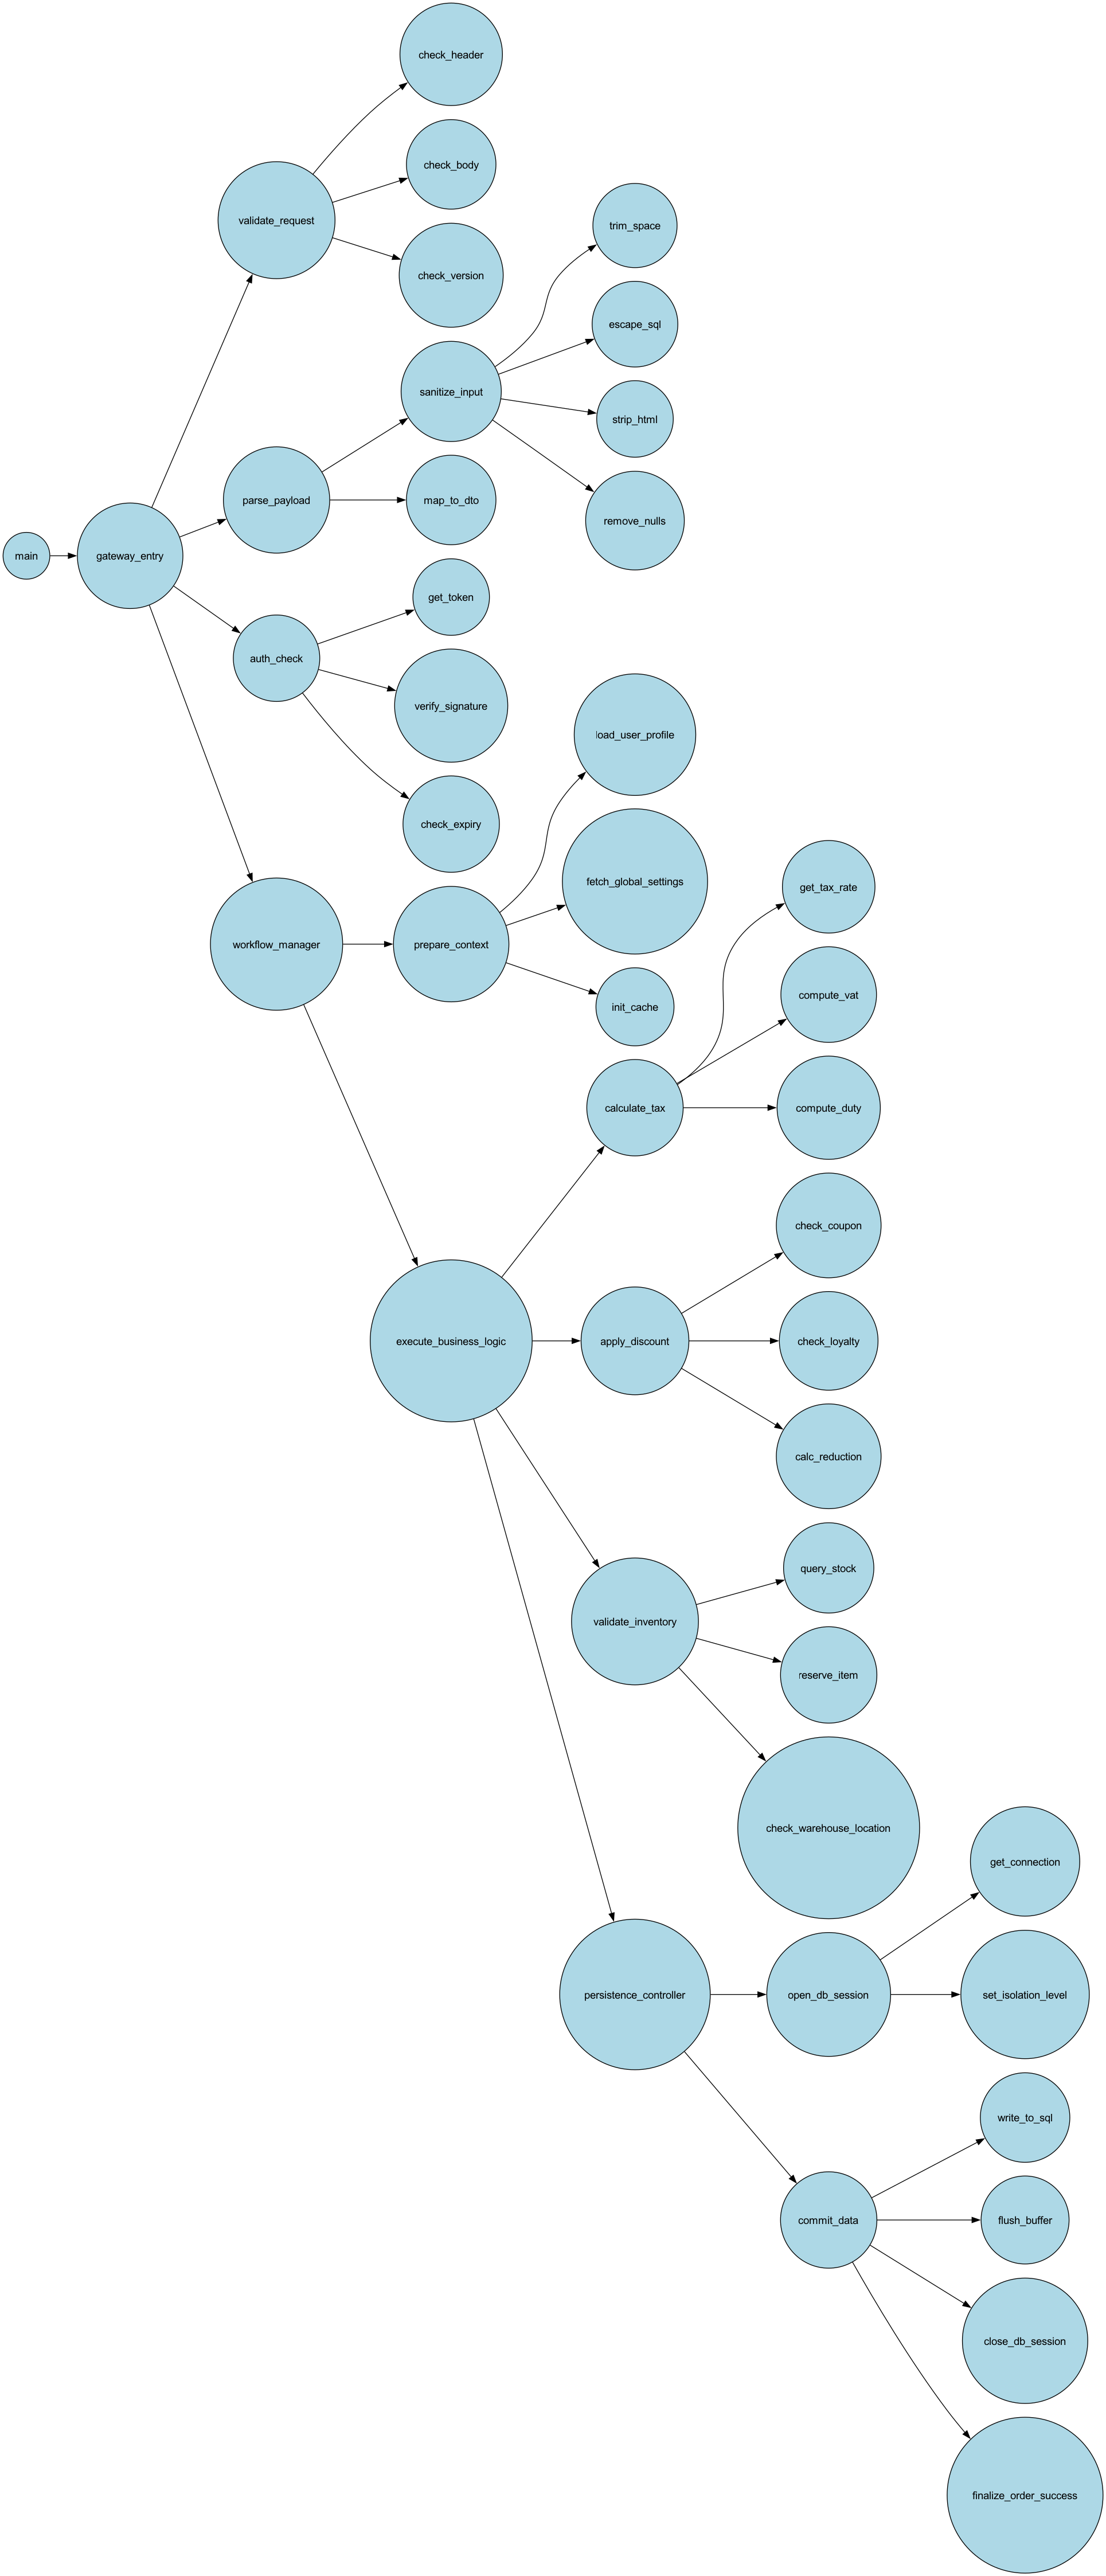

Visualisasi Call Graph t1


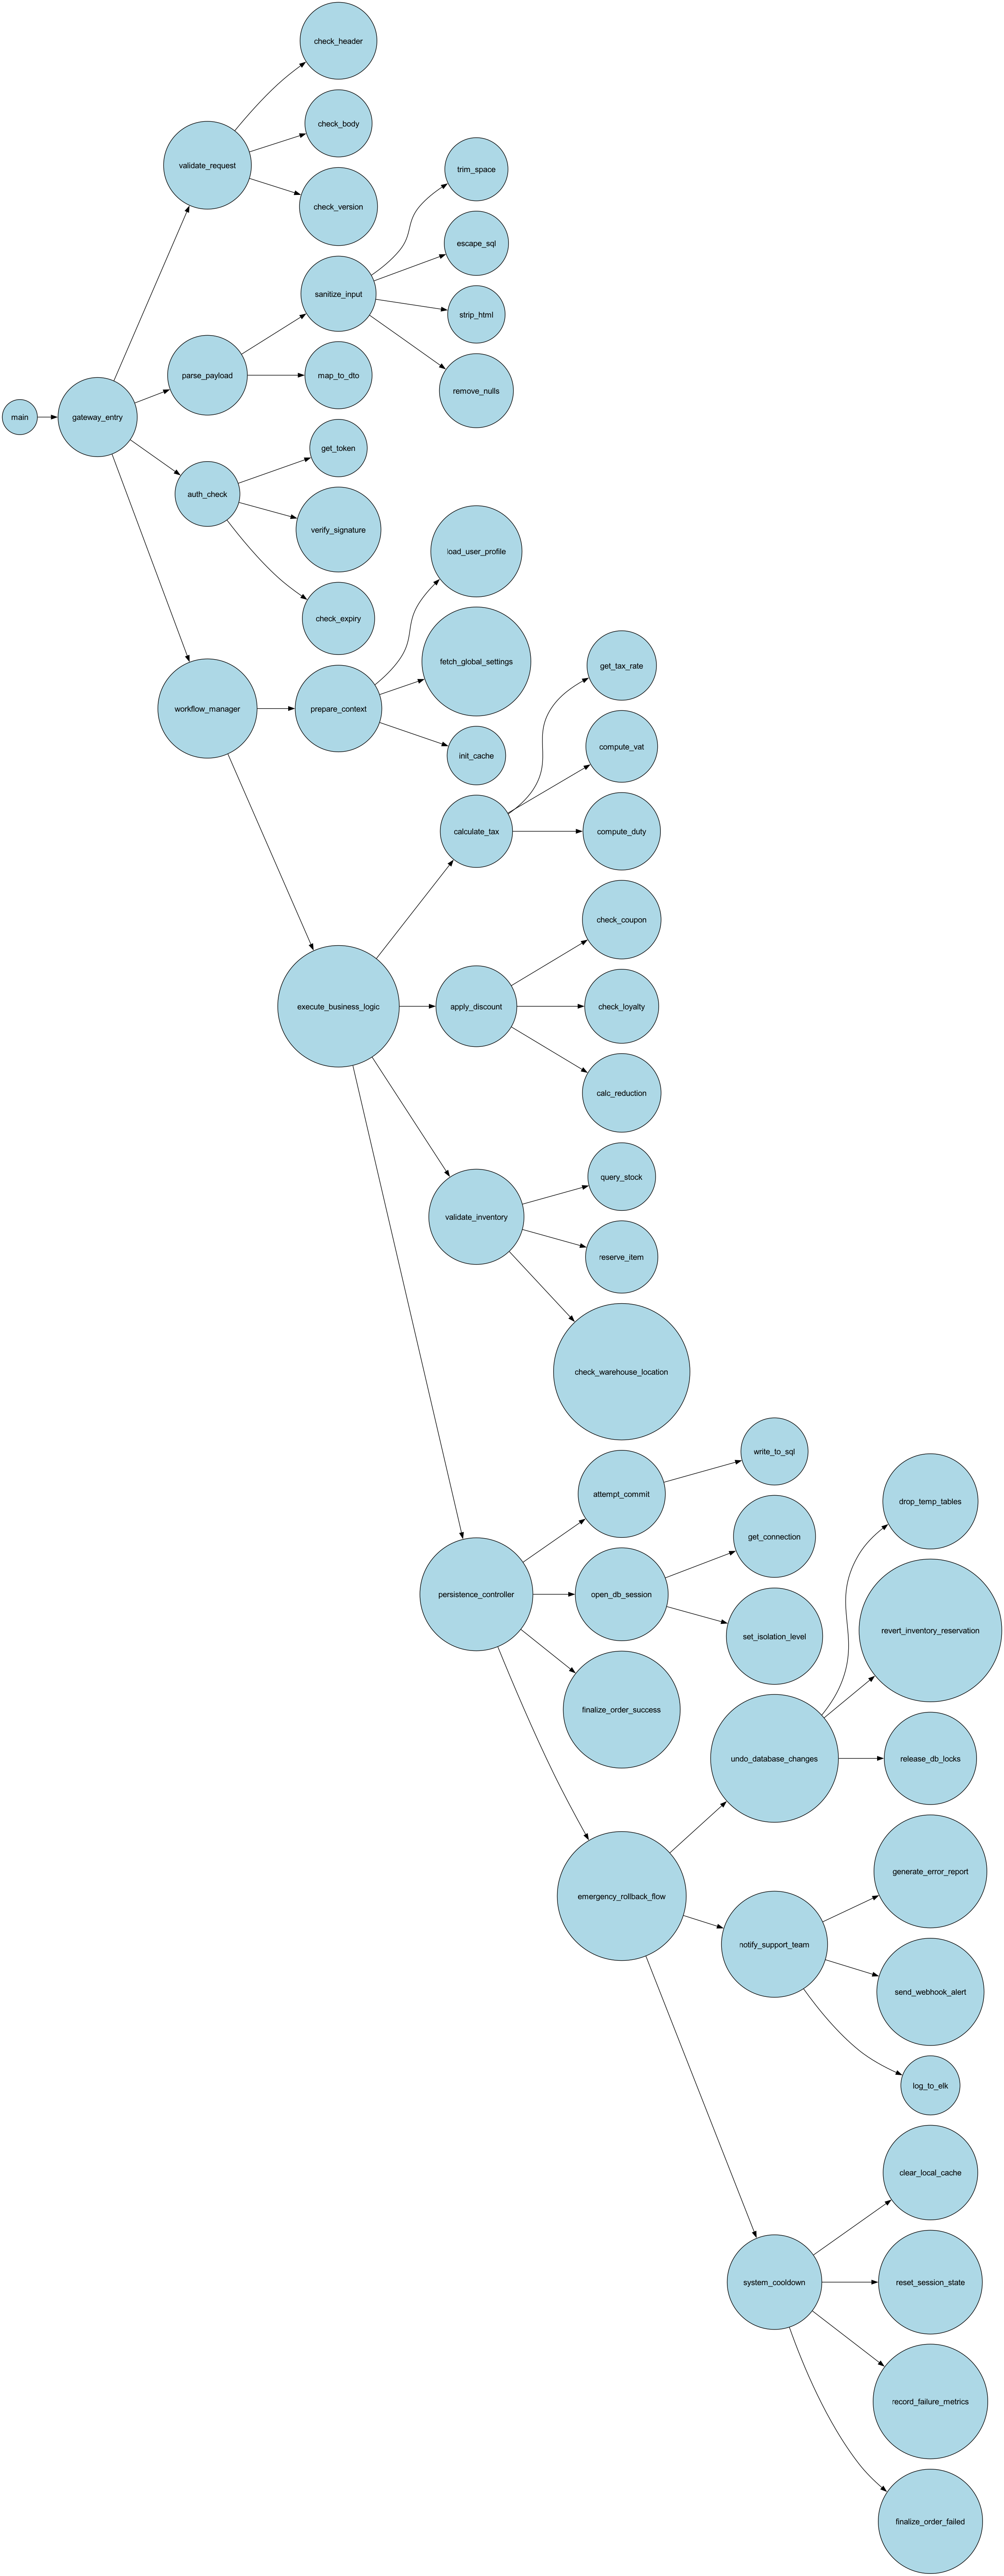

'call_graph_t1.png'

In [820]:
print("Visualisasi Call Graph t0")
show_graph(G_t0, "call_graph_t0", "Call Graph t0")

print("Visualisasi Call Graph t1")
show_graph(G_t1, "call_graph_t1", "Call Graph t1")

# Fungsi-fungsi pipeline HCSumm* / Proposed Method

## 5. Execution path dan fitur perilaku `f(v)`

Definisi yang digunakan:
- Execution path = simple path yang mengikuti arah edge dan berakhir di exit node.
- Exit node = node dengan out-degree 0.
- Node dihitung jika dilewati path, baik sebagai node awal, tengah, maupun akhir.
- `f(v,l)` = jumlah path panjang `l` yang memuat node `v`.

In [821]:
def get_exit_nodes(G):
    return [n for n in G.nodes() if G.out_degree(n) == 0]

def extract_execution_paths(G):
    exit_nodes = get_exit_nodes(G)
    paths = []

    for start in G.nodes():
        for end in exit_nodes:
            if start == end:
                continue
            try:
                for path in nx.all_simple_paths(G, start, end):
                    if len(path) > 1:
                        paths.append(path)
            except nx.NetworkXNoPath:
                pass

    # Remove duplicates while preserving order
    seen = set()
    unique_paths = []
    for p in paths:
        key = tuple(p)
        if key not in seen:
            seen.add(key)
            unique_paths.append(p)

    return unique_paths

def build_path_length_profile(G, paths):
    if not paths:
        return {n: np.array([], dtype=float) for n in G.nodes()}, 0

    L = max(len(p) - 1 for p in paths)
    f = {n: np.zeros(L, dtype=float) for n in G.nodes()}

    for p in paths:
        length = len(p) - 1
        idx = length - 1
        for v in p:
            f[v][idx] += 1

    return f, L

def build_compact_behavior_feature_epl(G, paths):
    # 1. Hitung path-length count profile lama
    f_path, L = build_path_length_profile(G, paths)

    # 2. Hitung EPL dan EPL'
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total_count = vec.sum()

        if total_count > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total_count
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree feature
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg = max(indeg.values()) if max(indeg.values()) > 0 else 1
    max_outdeg = max(outdeg.values()) if max(outdeg.values()) > 0 else 1

    # 4. Bentuk f_star compact:
    # f*(v) = [EPL'(v), indeg'(v), outdeg'(v)]
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, L

def normalize_f_l1(f):
    f_norm = {}
    for v, vec in f.items():
        s = vec.sum()
        if s > 0:
            f_norm[v] = vec / s
        else:
            f_norm[v] = vec.copy()
    return f_norm

def print_paths(paths):
    for i, p in enumerate(paths, 1):
        print(f"P{i}: {' -> '.join(map(str, p))} | length={len(p)-1}")

def features_to_dataframe(feat_dict, prefix="dim"):
    if not feat_dict:
        return pd.DataFrame()
    nodes = list(feat_dict.keys())
    max_len = max((len(v) for v in feat_dict.values()), default=0)
    data = []
    for n in nodes:
        vec = feat_dict[n]
        row = list(vec) + [np.nan] * (max_len - len(vec))
        data.append(row)
    cols = [f"{prefix}{i+1}" for i in range(max_len)]
    return pd.DataFrame(data, index=nodes, columns=cols)

def compute_node_depth(G):
    # root = semua node dengan indeg = 0
    roots = [n for n, d in G.in_degree() if d == 0]

    # inisialisasi depth
    depth = {v: float('inf') for v in G.nodes()}

    # BFS dari semua root
    from collections import deque

    queue = deque()
    for r in roots:
        depth[r] = 0
        queue.append(r)

    while queue:
        u = queue.popleft()
        for v in G.successors(u):
            if depth[v] > depth[u] + 1:
                depth[v] = depth[u] + 1
                queue.append(v)

    return depth
    
def build_compact_behavior_feature_epl(G, paths):
    import numpy as np

    # 1. Path-length profile
    f_path, L = build_path_length_profile(G, paths)

    # 2. EPL
    epl = {}
    epl_norm = {}

    for v, vec in f_path.items():
        total = vec.sum()
        if total > 0 and L > 0:
            lengths = np.arange(1, L + 1)
            epl[v] = np.sum(lengths * vec) / total
            epl_norm[v] = epl[v] / L
        else:
            epl[v] = 0.0
            epl_norm[v] = 0.0

    # 3. Degree
    indeg = dict(G.in_degree())
    outdeg = dict(G.out_degree())

    max_indeg = max(indeg.values()) if max(indeg.values()) > 0 else 1
    max_outdeg = max(outdeg.values()) if max(outdeg.values()) > 0 else 1

    # 4. Depth
    depth = compute_node_depth(G)
    max_depth = max([d for d in depth.values() if d < float('inf')]) if depth else 1

    depth_norm = {}
    for v in G.nodes():
        if depth[v] == float('inf'):
            depth_norm[v] = 1.0
        else:
            depth_norm[v] = depth[v] / max_depth if max_depth > 0 else 0.0

    # 5. Final f*(v)
    f_star = {}

    for v in G.nodes():
        indeg_norm = indeg[v] / max_indeg
        outdeg_norm = outdeg[v] / max_outdeg

        f_star[v] = np.array([
            epl_norm[v],
            indeg_norm,
            outdeg_norm,
            depth_norm[v]
        ])

    return f_star, f_path, epl, epl_norm, indeg, outdeg, depth, depth_norm, L

print("Execution path and f(v) functions ready.")

Execution path and f(v) functions ready.


## 6. Directed node2vec random walk

Bagian ini memastikan random walk hanya mengikuti **outgoing neighbors**.
Dengan demikian, sequence walk tetap mempertahankan arah pada call graph.

In [822]:
def directed_node2vec_walk(G, start_node, walk_length, p=1.0, q=1.0):
    walk = [start_node]

    while len(walk) < walk_length:
        curr = walk[-1]
        neighbors = list(G.successors(curr))  # penting: outgoing neighbors saja

        if len(neighbors) == 0:
            break  # exit node

        if len(walk) == 1:
            next_node = random.choice(neighbors)
        else:
            prev = walk[-2]
            weights = []

            for nbr in neighbors:
                if nbr == prev:
                    weight = 1.0 / p
                elif G.has_edge(prev, nbr) or G.has_edge(nbr, prev):
                    weight = 1.0
                else:
                    weight = 1.0 / q
                weights.append(weight)

            probs = np.array(weights, dtype=float)
            probs = probs / probs.sum()
            next_node = np.random.choice(neighbors, p=probs)

        walk.append(next_node)

    return walk

def generate_directed_node2vec_walks(G, num_walks=80, walk_length=10, p=1.0, q=1.0, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    nodes = list(G.nodes())
    walks = []

    for _ in range(num_walks):
        random.shuffle(nodes)
        for n in nodes:
            walk = directed_node2vec_walk(G, n, walk_length, p=p, q=q)
            walks.append([str(x) for x in walk])

    return walks

def compute_directed_node2vec_embedding(
    G,
    dimensions=4,
    walk_length=10,
    num_walks=200,
    p=1.0,
    q=1.0,
    seed=42,
    window=5,
    epochs=100
):
    walks = generate_directed_node2vec_walks(
        G,
        num_walks=num_walks,
        walk_length=walk_length,
        p=p,
        q=q,
        seed=seed
    )

    model = Word2Vec(
        sentences=walks,
        vector_size=dimensions,
        window=window,
        min_count=1,
        sg=1,          # skip-gram
        workers=1,
        seed=seed,
        epochs=epochs
    )

    e = {}
    for n in G.nodes():
        key = str(n)
        if key in model.wv:
            e[n] = model.wv[key]
        else:
            # fallback jika node tidak muncul dalam walk
            e[n] = np.zeros(dimensions)

    return e, walks, model

def normalize_e_l2(e):
    e_norm = {}
    for v, vec in e.items():
        norm = np.linalg.norm(vec)
        if norm > 0:
            e_norm[v] = vec / norm
        else:
            e_norm[v] = vec.copy()
    return e_norm

print("Directed node2vec functions ready.")

Directed node2vec functions ready.


## 7. Fusion, distance, Ward clustering, dan summary graph

In [823]:
def align_feature_dimensions(feat_dict, target_len):
    aligned = {}
    for n, vec in feat_dict.items():
        vec = np.asarray(vec, dtype=float)
        if len(vec) < target_len:
            vec = np.concatenate([vec, np.zeros(target_len - len(vec))])
        aligned[n] = vec
    return aligned

def fuse_features(e_norm, f_norm, alpha=1.0, beta=1.0):
    nodes = list(e_norm.keys())
    x = {}
    for n in nodes:
        x[n] = np.concatenate([alpha * e_norm[n], beta * f_norm[n]])
    return x

def compute_distance_matrix(x):
    nodes = list(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) <= 1:
        return nodes, np.zeros((len(nodes), len(nodes)))

    dist = squareform(pdist(X, metric="euclidean"))
    return nodes, dist

def ward_clustering(x, k=2):
    nodes = list(x.keys())
    X = np.array([x[n] for n in nodes])

    if len(nodes) == 0:
        return {}, None
    if len(nodes) == 1:
        return {1: [nodes[0]]}, None

    k = min(k, len(nodes))
    Z = linkage(X, method="ward")
    labels = fcluster(Z, k, criterion="maxclust")

    clusters = {}
    for i, n in enumerate(nodes):
        clusters.setdefault(int(labels[i]), []).append(n)

    return clusters, Z

def build_summary_graph(G, clusters):
    node_to_cluster = {}
    for cid, members in clusters.items():
        for n in members:
            node_to_cluster[n] = cid

    S = nx.DiGraph()
    for cid in clusters:
        S.add_node(f"C{cid}")

    for u, v in G.edges():
        cu = node_to_cluster.get(u)
        cv = node_to_cluster.get(v)
        if cu is not None and cv is not None and cu != cv:
            S.add_edge(f"C{cu}", f"C{cv}")

    return S, node_to_cluster

def print_clusters(clusters):
    for cid, members in sorted(clusters.items()):
        print(f"C{cid}: {members}")

print("Fusion, distance, clustering, and summary graph functions ready.")

Fusion, distance, clustering, and summary graph functions ready.


# Proses t0 satu per satu

## 8. t0 — Execution path

In [824]:
paths_t0 = extract_execution_paths(G_t0)
exit_t0 = get_exit_nodes(G_t0)

print("Exit nodes t0:", exit_t0)
print("\nExecution paths t0:")
print_paths(paths_t0)

Exit nodes t0: ['check_header', 'check_body', 'check_version', 'trim_space', 'escape_sql', 'strip_html', 'remove_nulls', 'map_to_dto', 'get_token', 'verify_signature', 'check_expiry', 'load_user_profile', 'fetch_global_settings', 'init_cache', 'get_tax_rate', 'compute_vat', 'compute_duty', 'check_coupon', 'check_loyalty', 'calc_reduction', 'query_stock', 'reserve_item', 'check_warehouse_location', 'get_connection', 'set_isolation_level', 'write_to_sql', 'flush_buffer', 'close_db_session', 'finalize_order_success']

Execution paths t0:
P1: main -> gateway_entry -> validate_request -> check_header | length=3
P2: main -> gateway_entry -> validate_request -> check_body | length=3
P3: main -> gateway_entry -> validate_request -> check_version | length=3
P4: main -> gateway_entry -> parse_payload -> sanitize_input -> trim_space | length=4
P5: main -> gateway_entry -> parse_payload -> sanitize_input -> escape_sql | length=4
P6: main -> gateway_entry -> parse_payload -> sanitize_input -> strip

## 9. t0 — Hitung `f(v)` dan normalisasi `f'(v)`

In [825]:
#f_t0, L_t0 = build_path_length_profile(G_t0, paths_t0)
#f_norm_t0 = normalize_f_l1(f_t0)
#f_star_t0, f_t0, f_norm_t0, indeg_t0, outdeg_t0, L_t0 = build_enriched_behavior_feature(G_t0, paths_t0)
f_star_t0, f_t0, epl_t0, epl_norm_t0, indeg_t0, outdeg_t0, depth_t0, depth_norm_t0, L_t0 = build_compact_behavior_feature_epl(G_t0, paths_t0)

print("L_t0 =", L_t0)

print("\nRaw f_path(v) t0:")
display(features_to_dataframe(f_t0, prefix="f"))

print("\nEPL(v) t0:")
display(pd.DataFrame.from_dict(epl_t0, orient="index", columns=["EPL"]))

print("\nEPL'(v) t0:")
display(pd.DataFrame.from_dict(epl_norm_t0, orient="index", columns=["EPL'"]))

print("\nIn-degree t0:")
display(pd.DataFrame.from_dict(indeg_t0, orient="index", columns=["indeg"]))

print("\nOut-degree t0:")
display(pd.DataFrame.from_dict(outdeg_t0, orient="index", columns=["outdeg"]))

print("\nDepth t0:")
display(pd.DataFrame.from_dict(depth_t0, orient="index", columns=["depth"]))

print("\nNormalized depth t0:")
display(pd.DataFrame.from_dict(depth_norm_t0, orient="index", columns=["depth'"]))

print("\nUpdated f*(v) t0:")
display(features_to_dataframe(f_star_t0, prefix="f*"))

#print("\nCompact behavior feature f*(v) t0:")
#display(features_to_dataframe(f_star_t0, prefix="f*"))

L_t0 = 6

Raw f_path(v) t0:


,f1,f2,f3,f4,f5,f6
main,0.0,0.0,7.0,7.0,9.0,6.0
gateway_entry,0.0,7.0,14.0,16.0,15.0,6.0
validate_request,3.0,3.0,3.0,0.0,0.0,0.0
check_header,1.0,1.0,1.0,0.0,0.0,0.0
check_body,1.0,1.0,1.0,0.0,0.0,0.0
check_version,1.0,1.0,1.0,0.0,0.0,0.0
parse_payload,1.0,5.0,5.0,4.0,0.0,0.0
sanitize_input,4.0,4.0,4.0,4.0,0.0,0.0
trim_space,1.0,1.0,1.0,1.0,0.0,0.0
escape_sql,1.0,1.0,1.0,1.0,0.0,0.0



EPL(v) t0:


,EPL
main,4.482759
gateway_entry,3.982759
validate_request,2.000000
check_header,2.000000
check_body,2.000000
check_version,2.000000
parse_payload,2.800000
sanitize_input,2.500000
trim_space,2.500000
escape_sql,2.500000



EPL'(v) t0:


...

,depth
main,0
gateway_entry,1
validate_request,2
check_header,3
check_body,3
check_version,3
parse_payload,2
sanitize_input,3
trim_space,4
escape_sql,4



Normalized depth t0:


,depth'
main,0.000000
gateway_entry,0.166667
validate_request,0.333333
check_header,0.500000
check_body,0.500000
check_version,0.500000
parse_payload,0.333333
sanitize_input,0.500000
trim_space,0.666667
escape_sql,0.666667



Updated f*(v) t0:


,f*1,f*2,f*3,f*4
main,0.747126,0.0,0.25,0.000000
gateway_entry,0.663793,1.0,1.00,0.166667
validate_request,0.333333,1.0,0.75,0.333333
check_header,0.333333,1.0,0.00,0.500000
check_body,0.333333,1.0,0.00,0.500000
check_version,0.333333,1.0,0.00,0.500000
parse_payload,0.466667,1.0,0.50,0.333333
sanitize_input,0.416667,1.0,1.00,0.500000
trim_space,0.416667,1.0,0.00,0.666667
escape_sql,0.416667,1.0,0.00,0.666667


## 10. t0 — Directed node2vec random walk dan embedding `e(v)`

In [826]:
e_t0, walks_t0, model_t0 = compute_directed_node2vec_embedding(
    G_t0,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t0:")
for w in walks_t0[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t0:")
display(features_to_dataframe(e_t0, prefix="e"))

Contoh 10 random walks t0:
escape_sql
check_header
strip_html
reserve_item
commit_data -> close_db_session
prepare_context -> fetch_global_settings
validate_inventory -> check_warehouse_location
compute_duty
check_body
persistence_controller -> commit_data -> flush_buffer

Raw e(v) t0:


,e1,e2,e3,e4
main,0.719392,0.215115,0.168581,0.932945
gateway_entry,0.752302,0.257155,0.244776,0.900668
validate_request,0.997773,0.170796,-1.729033,3.880110
check_header,1.508943,0.925658,-0.261927,2.941026
check_body,1.523904,0.994723,-0.410913,3.031924
check_version,1.599548,0.979484,-0.355922,3.315313
parse_payload,2.320678,-0.502992,2.213968,1.200210
sanitize_input,2.582694,-2.047899,3.266092,2.233377
trim_space,2.308270,0.462981,1.433298,1.202968
escape_sql,2.692437,0.457230,1.738049,1.558906


## 11. t0 — Normalisasi `e(v)` menjadi `e'(v)`

In [827]:
e_norm_t0 = normalize_e_l2(e_t0)

print("Normalized e'(v) t0:")
display(features_to_dataframe(e_norm_t0, prefix="e'"))

Normalized e'(v) t0:


,e'1,e'2,e'3,e'4
main,0.594843,0.177872,0.139395,0.771423
gateway_entry,0.613597,0.209742,0.199646,0.734608
validate_request,0.228487,0.039112,-0.395944,0.888534
check_header,0.438306,0.268878,-0.076083,0.854286
check_body,0.428070,0.279421,-0.115427,0.851678
check_version,0.418107,0.256028,-0.093035,0.866592
parse_payload,0.670461,-0.145318,0.639632,0.346750
sanitize_input,0.501522,-0.397673,0.634228,0.433690
trim_space,0.767552,0.153952,0.476604,0.400014
escape_sql,0.749367,0.127258,0.483739,0.433879


## 12. t0 — Fusion menjadi `x(v)`

In [828]:
# Pastikan dimensi f(v) konsisten dengan L lokal t0
#f_norm_t0_aligned = align_feature_dimensions(f_norm_t0, L_t0)

#x_t0 = fuse_features(e_norm_t0, f_norm_t0_aligned, alpha=1.0, beta=1.0)
x_t0 = fuse_features(e_norm_t0, f_star_t0, alpha=1.0, beta=1.0)

print("Fused representation x(v) t0:")
display(features_to_dataframe(x_t0, prefix="x"))

Fused representation x(v) t0:


,x1,x2,x3,x4,x5,x6,x7,x8
main,0.594843,0.177872,0.139395,0.771423,0.747126,0.0,0.25,0.000000
gateway_entry,0.613597,0.209742,0.199646,0.734608,0.663793,1.0,1.00,0.166667
validate_request,0.228487,0.039112,-0.395944,0.888534,0.333333,1.0,0.75,0.333333
check_header,0.438306,0.268878,-0.076083,0.854286,0.333333,1.0,0.00,0.500000
check_body,0.428070,0.279421,-0.115427,0.851678,0.333333,1.0,0.00,0.500000
check_version,0.418107,0.256028,-0.093035,0.866592,0.333333,1.0,0.00,0.500000
parse_payload,0.670461,-0.145318,0.639632,0.346750,0.466667,1.0,0.50,0.333333
sanitize_input,0.501522,-0.397673,0.634228,0.433690,0.416667,1.0,1.00,0.500000
trim_space,0.767552,0.153952,0.476604,0.400014,0.416667,1.0,0.00,0.666667
escape_sql,0.749367,0.127258,0.483739,0.433879,0.416667,1.0,0.00,0.666667


## 13. t0 — Euclidean distance berdasarkan `x(v)`

In [829]:
nodes_t0, dist_t0 = compute_distance_matrix(x_t0)

dist_df_t0 = pd.DataFrame(dist_t0, index=nodes_t0, columns=nodes_t0)
print("Distance matrix t0:")
display(dist_df_t0.round(4))

Distance matrix t0:


,main,gateway_entry,validate_request,check_header,check_body,check_version,parse_payload,sanitize_input,trim_space,escape_sql,...,check_warehouse_location,persistence_controller,open_db_session,get_connection,set_isolation_level,commit_data,write_to_sql,flush_buffer,close_db_session,finalize_order_success
main,0.0000,1.2663,1.4093,1.2529,1.2622,1.2586,1.3390,1.6188,1.3778,1.3693,...,1.8490,1.7302,1.7176,1.8156,1.8171,1.9922,1.9165,1.9224,1.9200,1.9277
gateway_entry,1.2663,0.0000,0.8691,1.1597,1.1716,1.1678,0.8888,0.9127,1.2355,1.2278,...,1.7649,1.4437,1.3951,1.7437,1.7451,1.4922,1.8274,1.8329,1.8321,1.8388
validate_request,1.4093,0.8691,0.0000,0.8891,0.8763,0.8749,1.2944,1.2770,1.4087,1.3929,...,1.5867,1.0815,1.0662,1.2289,1.2319,1.2682,1.5848,1.5996,1.5803,1.6017
check_header,1.2529,1.1597,0.8891,0.0000,0.0421,0.0318,1.1362,1.4617,0.8174,0.8010,...,1.4150,1.3023,1.1825,1.1259,1.1292,1.6794,1.4010,1.4153,1.4042,1.4216
check_body,1.2622,1.1716,0.8763,0.0421,0.0000,0.0370,1.1661,1.4858,0.8487,0.8335,...,1.4200,1.2837,1.1616,1.1055,1.1089,1.6695,1.3927,1.4079,1.3959,1.4142
check_version,1.2586,1.1678,0.8749,0.0318,0.0370,0.0000,1.1521,1.4689,0.8423,0.8252,...,1.4156,1.2960,1.1807,1.1119,1.1154,1.6757,1.4025,1.4171,1.4051,1.4232
parse_payload,1.3390,0.8888,1.2944,1.1362,1.1661,1.1521,0.0000,0.6165,0.7014,0.6899,...,1.2969,1.5305,1.5268,1.6864,1.6859,1.5842,1.5589,1.5496,1.5631,1.5549
sanitize_input,1.6188,0.9127,1.2770,1.4617,1.4858,1.4689,0.6165,0.0000,1.1953,1.1779,...,1.4653,1.5985,1.6315,1.8156,1.8151,1.4454,1.7569,1.7466,1.7547,1.7491
trim_space,1.3778,1.2355,1.4087,0.8174,0.8487,0.8423,0.7014,1.1953,0.0000,0.0473,...,1.2153,1.5036,1.3901,1.4417,1.4418,1.7288,1.3236,1.3210,1.3346,1.3298
escape_sql,1.3693,1.2278,1.3929,0.8010,0.8335,0.8252,0.6899,1.1779,0.0473,0.0000,...,1.2107,1.5064,1.3988,1.4337,1.4339,1.7306,1.3327,1.3300,1.3426,1.3385


## 14. t0 — Ward clustering

In [830]:
clusters_t0, Z_t0 = ward_clustering(x_t0, k=K_CLUSTERS)

print("Clusters t0:")
print_clusters(clusters_t0)

if Z_t0 is not None:
    print("\nWard linkage matrix t0:")
    display(pd.DataFrame(Z_t0, columns=["cluster_1", "cluster_2", "distance", "size"]))

def explain_ward_merges(Z, nodes):
    cluster_map = {i: [nodes[i]] for i in range(len(nodes))}

    print("\nUrutan merge Ward clustering:")
    for step, row in enumerate(Z, start=1):
        c1, c2, dist, size = row
        c1 = int(c1)
        c2 = int(c2)

        members_1 = cluster_map[c1]
        members_2 = cluster_map[c2]

        new_cluster = members_1 + members_2
        new_id = len(nodes) + step - 1
        cluster_map[new_id] = new_cluster

        print(f"Iterasi {step}: merge {members_1} + {members_2} -> {new_cluster}")
        print(f"  linkage distance = {dist:.4f}, size = {int(size)}")

if Z_t0 is not None:
    explain_ward_merges(Z_t0, list(x_t0.keys()))

Clusters t0:
C1: ['check_header', 'check_body', 'check_version', 'trim_space', 'escape_sql', 'strip_html', 'remove_nulls', 'map_to_dto', 'get_token', 'verify_signature', 'check_expiry', 'load_user_profile', 'fetch_global_settings', 'init_cache', 'check_coupon', 'check_loyalty', 'calc_reduction']
C2: ['get_tax_rate', 'compute_vat', 'compute_duty', 'query_stock', 'reserve_item', 'check_warehouse_location', 'get_connection', 'set_isolation_level', 'write_to_sql', 'flush_buffer', 'close_db_session', 'finalize_order_success']
C3: ['main', 'gateway_entry', 'validate_request', 'parse_payload', 'sanitize_input', 'auth_check', 'workflow_manager', 'prepare_context', 'execute_business_logic', 'calculate_tax', 'apply_discount', 'validate_inventory', 'persistence_controller', 'open_db_session', 'commit_data']

Ward linkage matrix t0:


,cluster_1,cluster_2,distance,size
0,37.0,38.0,0.006803,2.0
1,20.0,21.0,0.009871,2.0
2,32.0,34.0,0.010172,2.0
3,41.0,43.0,0.014732,2.0
4,28.0,29.0,0.019681,2.0
5,19.0,45.0,0.021455,3.0
6,10.0,11.0,0.021802,2.0
7,14.0,16.0,0.023225,2.0
8,9.0,50.0,0.027392,3.0
9,33.0,46.0,0.029620,3.0



Urutan merge Ward clustering:
Iterasi 1: merge ['get_connection'] + ['set_isolation_level'] -> ['get_connection', 'set_isolation_level']
  linkage distance = 0.0068, size = 2
Iterasi 2: merge ['fetch_global_settings'] + ['init_cache'] -> ['fetch_global_settings', 'init_cache']
  linkage distance = 0.0099, size = 2
Iterasi 3: merge ['query_stock'] + ['check_warehouse_location'] -> ['query_stock', 'check_warehouse_location']
  linkage distance = 0.0102, size = 2
Iterasi 4: merge ['flush_buffer'] + ['finalize_order_success'] -> ['flush_buffer', 'finalize_order_success']
  linkage distance = 0.0147, size = 2
Iterasi 5: merge ['check_coupon'] + ['check_loyalty'] -> ['check_coupon', 'check_loyalty']
  linkage distance = 0.0197, size = 2
Iterasi 6: merge ['load_user_profile'] + ['fetch_global_settings', 'init_cache'] -> ['load_user_profile', 'fetch_global_settings', 'init_cache']
  linkage distance = 0.0215, size = 3
Iterasi 7: merge ['strip_html'] + ['remove_nulls'] -> ['strip_html', 'remov

## 15. t0 — Summary graph

Node to cluster mapping t0:
{'main': 3, 'gateway_entry': 3, 'validate_request': 3, 'parse_payload': 3, 'sanitize_input': 3, 'auth_check': 3, 'workflow_manager': 3, 'prepare_context': 3, 'execute_business_logic': 3, 'calculate_tax': 3, 'apply_discount': 3, 'validate_inventory': 3, 'persistence_controller': 3, 'open_db_session': 3, 'commit_data': 3, 'check_header': 1, 'check_body': 1, 'check_version': 1, 'trim_space': 1, 'escape_sql': 1, 'strip_html': 1, 'remove_nulls': 1, 'map_to_dto': 1, 'get_token': 1, 'verify_signature': 1, 'check_expiry': 1, 'load_user_profile': 1, 'fetch_global_settings': 1, 'init_cache': 1, 'check_coupon': 1, 'check_loyalty': 1, 'calc_reduction': 1, 'get_tax_rate': 2, 'compute_vat': 2, 'compute_duty': 2, 'query_stock': 2, 'reserve_item': 2, 'check_warehouse_location': 2, 'get_connection': 2, 'set_isolation_level': 2, 'write_to_sql': 2, 'flush_buffer': 2, 'close_db_session': 2, 'finalize_order_success': 2}

Summary graph edges t0:
[('C3', 'C1'), ('C3', 'C2')]

Visu

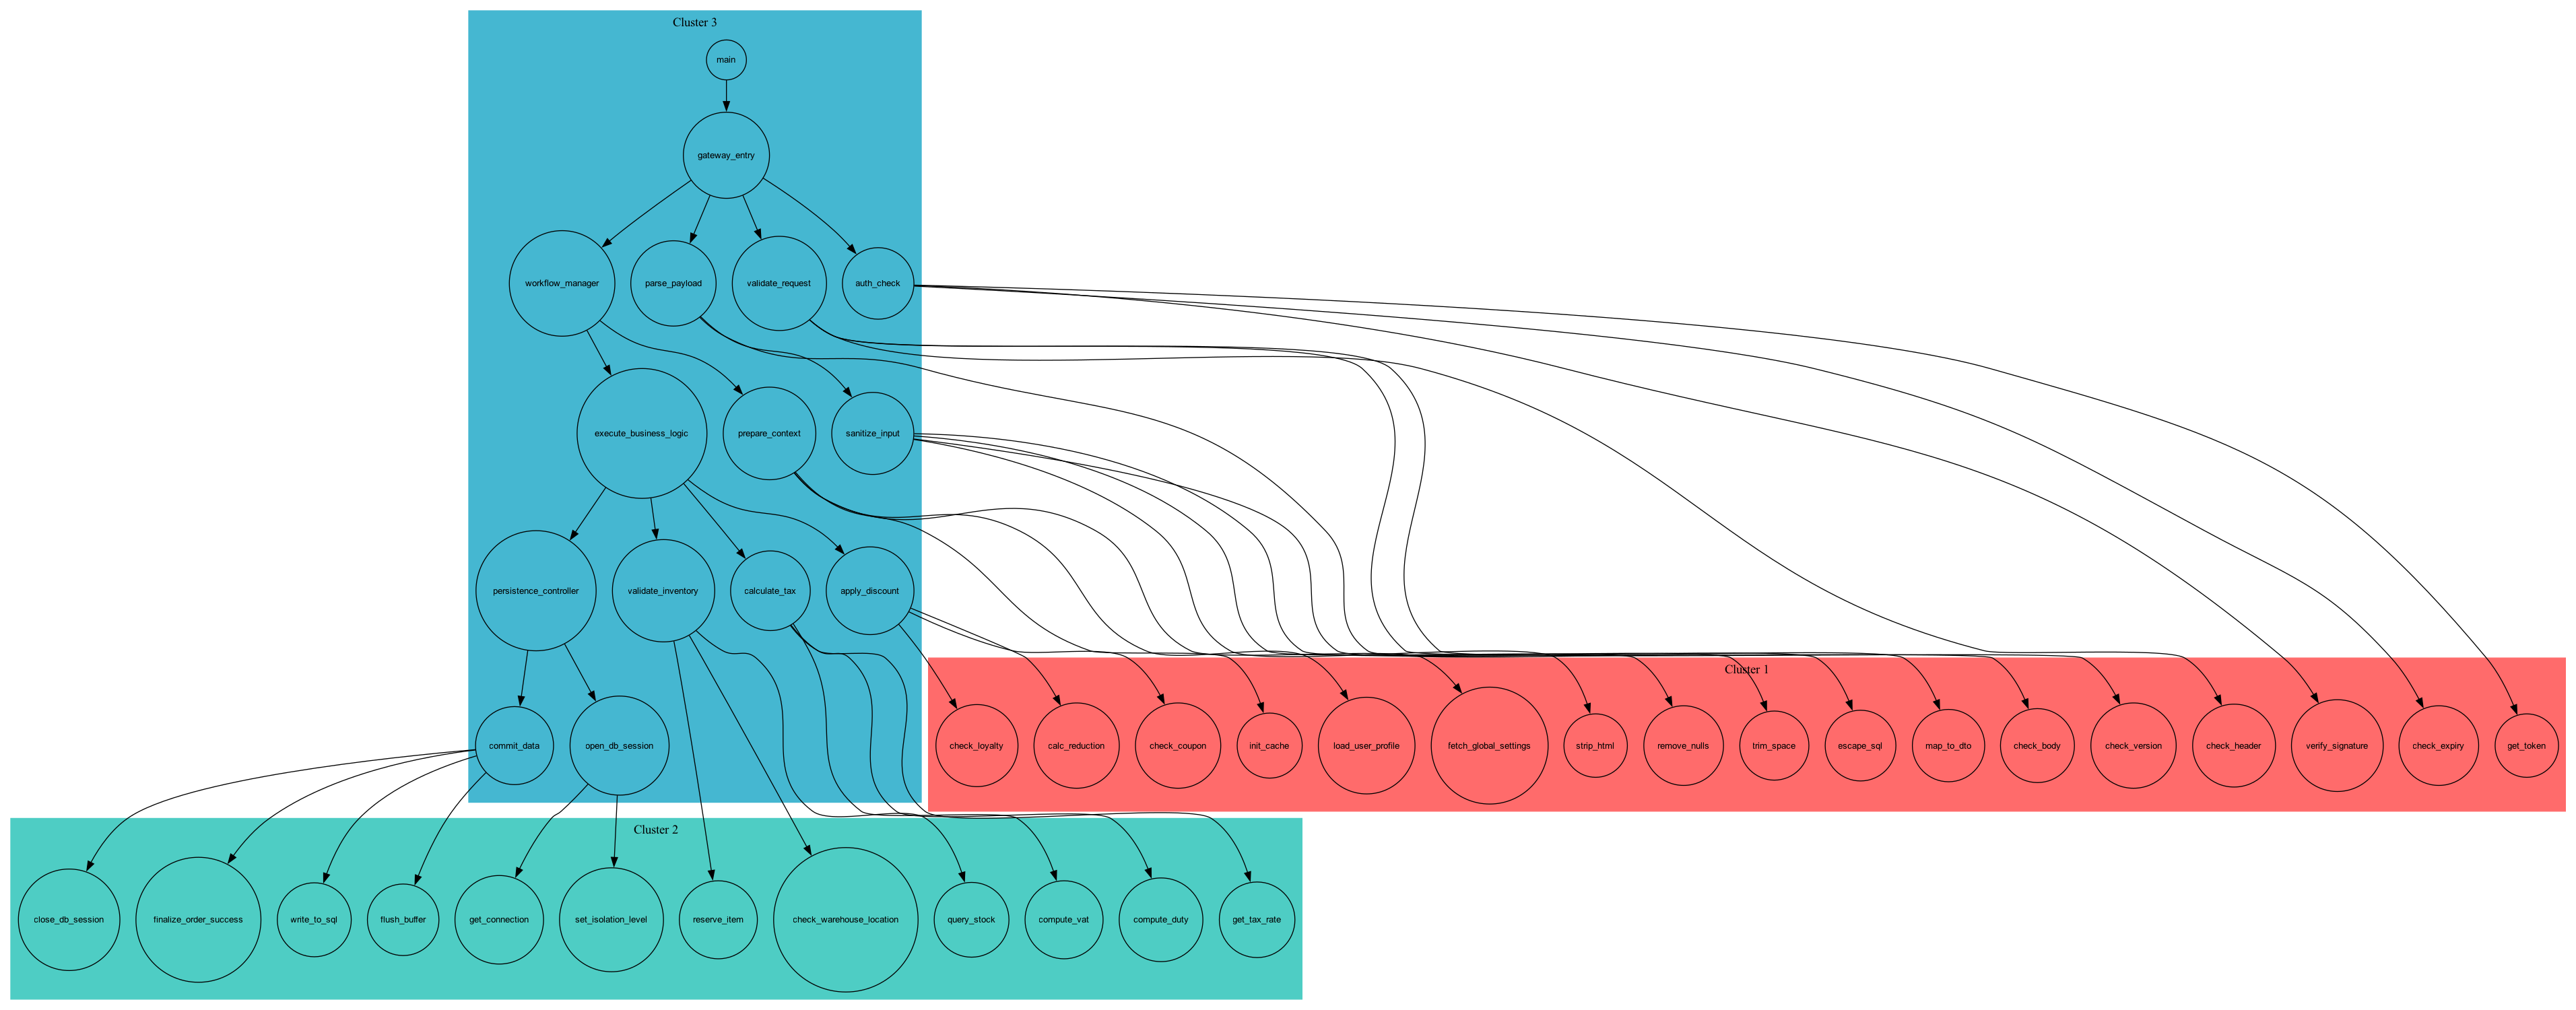


Visualisasi Summary Graph t0 (Cluster-only View)


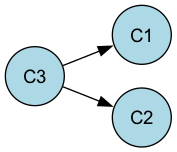

'summary_graph_t0_clusters_only.png'

In [831]:
S_t0, node_to_cluster_t0 = build_summary_graph(G_t0, clusters_t0)

print("Node to cluster mapping t0:")
print(node_to_cluster_t0)

print("\nSummary graph edges t0:")
print(list(S_t0.edges()))

print("\nVisualisasi Summary Graph t0 (Original Call Graph with Cluster Colors)")
show_graph_with_clusters(G_t0, node_to_cluster_t0, clusters_t0, "summary_graph_t0", "Call Graph with Clusters - t0")

print("\nVisualisasi Summary Graph t0 (Cluster-only View)")
show_graph(S_t0, "summary_graph_t0_clusters_only", "Summary Graph t0 (Clusters Only)")

# Proses t1 satu per satu

## 16. t1 — Execution path

In [832]:
paths_t1 = extract_execution_paths(G_t1)
exit_t1 = get_exit_nodes(G_t1)

print("Exit nodes t1:", exit_t1)
print("\nExecution paths t1:")
print_paths(paths_t1)

Exit nodes t1: ['check_header', 'check_body', 'check_version', 'trim_space', 'escape_sql', 'strip_html', 'remove_nulls', 'map_to_dto', 'get_token', 'verify_signature', 'check_expiry', 'load_user_profile', 'fetch_global_settings', 'init_cache', 'get_tax_rate', 'compute_vat', 'compute_duty', 'check_coupon', 'check_loyalty', 'calc_reduction', 'query_stock', 'reserve_item', 'check_warehouse_location', 'write_to_sql', 'get_connection', 'set_isolation_level', 'finalize_order_success', 'drop_temp_tables', 'revert_inventory_reservation', 'release_db_locks', 'generate_error_report', 'send_webhook_alert', 'log_to_elk', 'clear_local_cache', 'reset_session_state', 'record_failure_metrics', 'finalize_order_failed']

Execution paths t1:
P1: main -> gateway_entry -> validate_request -> check_header | length=3
P2: main -> gateway_entry -> validate_request -> check_body | length=3
P3: main -> gateway_entry -> validate_request -> check_version | length=3
P4: main -> gateway_entry -> parse_payload -> san

## 17. t1 — Hitung `f(v)` dan normalisasi `f'(v)`

In [833]:
#f_t1, L_t1 = build_path_length_profile(G_t1, paths_t1)
#f_norm_t1 = normalize_f_l1(f_t1)

f_star_t1, f_t1, epl_t1, epl_norm_t1, indeg_t1, outdeg_t1, depth_t1, depth_norm_t1, L_t1 = build_compact_behavior_feature_epl(G_t1, paths_t1)

print("L_t1 =", L_t1)

print("\nRaw f_path(v) t1:")
display(features_to_dataframe(f_t1, prefix="f"))

print("\nEPL(v) t1:")
display(pd.DataFrame.from_dict(epl_t1, orient="index", columns=["EPL"]))

print("\nEPL'(v) t1:")
display(pd.DataFrame.from_dict(epl_norm_t1, orient="index", columns=["EPL'"]))

print("\nIn-degree t1:")
display(pd.DataFrame.from_dict(indeg_t1, orient="index", columns=["indeg"]))

print("\nOut-degree t1:")
display(pd.DataFrame.from_dict(outdeg_t1, orient="index", columns=["outdeg"]))

print("\nDepth t1:")
display(pd.DataFrame.from_dict(depth_t1, orient="index", columns=["depth"]))

print("\nNormalized depth t1:")
display(pd.DataFrame.from_dict(depth_norm_t1, orient="index", columns=["depth'"]))

print("\nUpdated f*(v) t1:")
display(features_to_dataframe(f_star_t1, prefix="f*"))

L_t1 = 7

Raw f_path(v) t1:


,f1,f2,f3,f4,f5,f6,f7
main,0.0,0.0,7.0,7.0,10.0,3.0,10.0
gateway_entry,0.0,7.0,14.0,17.0,13.0,13.0,10.0
validate_request,3.0,3.0,3.0,0.0,0.0,0.0,0.0
check_header,1.0,1.0,1.0,0.0,0.0,0.0,0.0
check_body,1.0,1.0,1.0,0.0,0.0,0.0,0.0
check_version,1.0,1.0,1.0,0.0,0.0,0.0,0.0
parse_payload,1.0,5.0,5.0,4.0,0.0,0.0,0.0
sanitize_input,4.0,4.0,4.0,4.0,0.0,0.0,0.0
trim_space,1.0,1.0,1.0,1.0,0.0,0.0,0.0
escape_sql,1.0,1.0,1.0,1.0,0.0,0.0,0.0



EPL(v) t1:


,EPL
main,5.054054
gateway_entry,4.554054
validate_request,2.000000
check_header,2.000000
check_body,2.000000
check_version,2.000000
parse_payload,2.800000
sanitize_input,2.500000
trim_space,2.500000
escape_sql,2.500000



EPL'(v) t1:


...

,depth
main,0
gateway_entry,1
validate_request,2
check_header,3
check_body,3
check_version,3
parse_payload,2
sanitize_input,3
trim_space,4
escape_sql,4



Normalized depth t1:


,depth'
main,0.000000
gateway_entry,0.142857
validate_request,0.285714
check_header,0.428571
check_body,0.428571
check_version,0.428571
parse_payload,0.285714
sanitize_input,0.428571
trim_space,0.571429
escape_sql,0.571429



Updated f*(v) t1:


,f*1,f*2,f*3,f*4
main,0.722008,0.0,0.25,0.000000
gateway_entry,0.650579,1.0,1.00,0.142857
validate_request,0.285714,1.0,0.75,0.285714
check_header,0.285714,1.0,0.00,0.428571
check_body,0.285714,1.0,0.00,0.428571
check_version,0.285714,1.0,0.00,0.428571
parse_payload,0.400000,1.0,0.50,0.285714
sanitize_input,0.357143,1.0,1.00,0.428571
trim_space,0.357143,1.0,0.00,0.571429
escape_sql,0.357143,1.0,0.00,0.571429


## 18. t1 — Directed node2vec random walk dan embedding `e(v)`

In [834]:
e_t1, walks_t1, model_t1 = compute_directed_node2vec_embedding(
    G_t1,
    dimensions=EMBED_DIM,
    walk_length=WALK_LENGTH,
    num_walks=NUM_WALKS,
    p=P_RETURN,
    q=Q_INOUT,
    seed=SEED
)

print("Contoh 10 random walks t1:")
for w in walks_t1[:10]:
    print(" -> ".join(w))

print("\nRaw e(v) t1:")
display(features_to_dataframe(e_t1, prefix="e"))

Contoh 10 random walks t1:
calc_reduction
calculate_tax -> compute_duty
log_to_elk
remove_nulls
check_expiry
fetch_global_settings
system_cooldown -> record_failure_metrics
record_failure_metrics
persistence_controller -> attempt_commit -> write_to_sql
load_user_profile

Raw e(v) t1:


,e1,e2,e3,e4
main,-1.339562,-0.369753,-0.493549,0.517154
gateway_entry,-1.247870,-0.307042,-0.364346,0.446210
validate_request,-3.209613,-0.156531,0.549415,0.995011
check_header,-3.629272,-0.380729,0.208467,1.373925
check_body,-3.801831,-0.396270,0.366382,1.502373
check_version,-3.637838,-0.398863,0.204512,1.452178
parse_payload,-1.858832,-0.989659,-0.719414,3.041261
sanitize_input,-1.324039,-2.412647,-1.347018,4.200818
trim_space,-2.113539,-0.673578,0.731624,2.892911
escape_sql,-2.315616,-0.705944,0.812006,3.021214


## 19. t1 — Normalisasi `e(v)` menjadi `e'(v)`

In [835]:
e_norm_t1 = normalize_e_l2(e_t1)

print("Normalized e'(v) t1:")
display(features_to_dataframe(e_norm_t1, prefix="e'"))

Normalized e'(v) t1:


,e'1,e'2,e'3,e'4
main,-0.857183,-0.236604,-0.315821,0.330926
gateway_entry,-0.886083,-0.218023,-0.258714,0.316843
validate_request,-0.941644,-0.045923,0.161189,0.291919
check_header,-0.929431,-0.097502,0.053387,0.351853
check_body,-0.922017,-0.096103,0.088855,0.364354
check_version,-0.922715,-0.101169,0.051873,0.368336
parse_payload,-0.493257,-0.262614,-0.190903,0.807024
sanitize_input,-0.254645,-0.464011,-0.259065,0.807920
trim_space,-0.568432,-0.181157,0.196769,0.778042
escape_sql,-0.585388,-0.178463,0.205275,0.763763


## 20. t1 — Fusion menjadi `x(v)`

In [836]:
x_t1 = fuse_features(e_norm_t1, f_star_t1, alpha=1.0, beta=1.0)

print("Fused representation x(v) t1:")
display(features_to_dataframe(x_t1, prefix="x"))

Fused representation x(v) t1:


,x1,x2,x3,x4,x5,x6,x7,x8
main,-0.857183,-0.236604,-0.315821,0.330926,0.722008,0.0,0.25,0.000000
gateway_entry,-0.886083,-0.218023,-0.258714,0.316843,0.650579,1.0,1.00,0.142857
validate_request,-0.941644,-0.045923,0.161189,0.291919,0.285714,1.0,0.75,0.285714
check_header,-0.929431,-0.097502,0.053387,0.351853,0.285714,1.0,0.00,0.428571
check_body,-0.922017,-0.096103,0.088855,0.364354,0.285714,1.0,0.00,0.428571
check_version,-0.922715,-0.101169,0.051873,0.368336,0.285714,1.0,0.00,0.428571
parse_payload,-0.493257,-0.262614,-0.190903,0.807024,0.400000,1.0,0.50,0.285714
sanitize_input,-0.254645,-0.464011,-0.259065,0.807920,0.357143,1.0,1.00,0.428571
trim_space,-0.568432,-0.181157,0.196769,0.778042,0.357143,1.0,0.00,0.571429
escape_sql,-0.585388,-0.178463,0.205275,0.763763,0.357143,1.0,0.00,0.571429


## 21. t1 — Euclidean distance berdasarkan `x(v)`

In [837]:
nodes_t1, dist_t1 = compute_distance_matrix(x_t1)

dist_df_t1 = pd.DataFrame(dist_t1, index=nodes_t1, columns=nodes_t1)
print("Distance matrix t1:")
display(dist_df_t1.round(4))

Distance matrix t1:


,main,gateway_entry,validate_request,check_header,check_body,check_version,parse_payload,sanitize_input,trim_space,escape_sql,...,release_db_locks,notify_support_team,generate_error_report,send_webhook_alert,log_to_elk,system_cooldown,clear_local_cache,reset_session_state,record_failure_metrics,finalize_order_failed
main,0.0000,1.2620,1.3396,1.2641,1.2749,1.2632,1.2741,1.5890,1.4392,1.4347,...,1.8744,2.0070,1.9601,1.9578,1.9555,1.9387,1.9699,1.9763,1.9771,1.9811
gateway_entry,1.2620,0.0000,0.6524,1.1532,1.1636,1.1528,0.8570,0.9317,1.3387,1.3330,...,1.7564,1.6057,1.8703,1.8686,1.8662,1.3736,1.8770,1.8840,1.8832,1.8876
validate_request,1.3396,0.6524,0.0000,0.7752,0.7722,0.7772,0.8443,1.0852,1.0220,1.0091,...,1.3993,1.5244,1.6931,1.6965,1.6946,1.1659,1.6750,1.6860,1.6735,1.6773
check_header,1.2641,1.1532,0.7752,0.0000,0.0384,0.0182,0.8763,1.3785,0.6042,0.5858,...,1.1407,1.6632,1.4397,1.4416,1.4393,1.4870,1.4271,1.4401,1.4294,1.4337
check_body,1.2749,1.1636,0.7722,0.0384,0.0000,0.0375,0.8771,1.3797,0.5836,0.5645,...,1.1151,1.6551,1.4258,1.4280,1.4258,1.4670,1.4112,1.4248,1.4132,1.4173
check_version,1.2632,1.1528,0.7772,0.0182,0.0375,0.0000,0.8633,1.3686,0.5885,0.5702,...,1.1370,1.6629,1.4325,1.4342,1.4320,1.4818,1.4204,1.4338,1.4233,1.4274
parse_payload,1.2741,0.8570,0.8443,0.8763,0.8771,0.8633,0.0000,0.6119,0.7049,0.7126,...,1.3767,1.5431,1.3799,1.3720,1.3724,1.2308,1.4019,1.4197,1.4254,1.4231
sanitize_input,1.5890,0.9317,1.0852,1.3785,1.3797,1.3686,0.6119,0.0000,1.1864,1.1954,...,1.6164,1.3953,1.4767,1.4671,1.4675,1.1111,1.5099,1.5220,1.5344,1.5320
trim_space,1.4392,1.3387,1.0220,0.6042,0.5836,0.5885,0.7049,1.1864,0.0000,0.0239,...,0.8768,1.5619,1.0915,1.0891,1.0900,1.2389,1.0846,1.1105,1.1024,1.0991
escape_sql,1.4347,1.3330,1.0091,0.5858,0.5645,0.5702,0.7126,1.1954,0.0239,0.0000,...,0.8699,1.5601,1.0976,1.0956,1.0964,1.2375,1.0892,1.1148,1.1061,1.1031


## 22. t1 — Ward clustering

In [838]:
clusters_t1, Z_t1 = ward_clustering(x_t1, k=K_CLUSTERS)

print("Clusters t1:")
print_clusters(clusters_t1)

if Z_t1 is not None:
    print("\nWard linkage matrix t1:")
    display(pd.DataFrame(Z_t1, columns=["cluster_1", "cluster_2", "distance", "size"]))

if Z_t1 is not None:
    explain_ward_merges(Z_t1, list(x_t1.keys()))

Clusters t1:
C1: ['main', 'gateway_entry', 'validate_request', 'check_header', 'check_body', 'check_version', 'parse_payload', 'sanitize_input', 'trim_space', 'escape_sql', 'strip_html', 'remove_nulls', 'map_to_dto', 'auth_check', 'get_token', 'verify_signature', 'check_expiry', 'prepare_context', 'load_user_profile', 'fetch_global_settings', 'init_cache']
C2: ['workflow_manager', 'execute_business_logic', 'calculate_tax', 'get_tax_rate', 'compute_vat', 'compute_duty', 'apply_discount', 'validate_inventory', 'query_stock', 'reserve_item', 'check_warehouse_location']
C3: ['check_coupon', 'check_loyalty', 'calc_reduction', 'persistence_controller', 'attempt_commit', 'write_to_sql', 'open_db_session', 'get_connection', 'set_isolation_level', 'finalize_order_success', 'emergency_rollback_flow', 'undo_database_changes', 'drop_temp_tables', 'revert_inventory_reservation', 'release_db_locks', 'notify_support_team', 'generate_error_report', 'send_webhook_alert', 'log_to_elk', 'system_cooldown'

,cluster_1,cluster_2,distance,size
0,49.0,50.0,0.009678,2.0
1,44.0,46.0,0.012243,2.0
2,20.0,21.0,0.012539,2.0
3,24.0,26.0,0.016778,2.0
4,3.0,5.0,0.018236,2.0
5,8.0,11.0,0.018540,2.0
6,28.0,30.0,0.020380,2.0
7,54.0,55.0,0.021496,2.0
8,39.0,40.0,0.022753,2.0
9,29.0,62.0,0.024794,3.0



Urutan merge Ward clustering:
Iterasi 1: merge ['send_webhook_alert'] + ['log_to_elk'] -> ['send_webhook_alert', 'log_to_elk']
  linkage distance = 0.0097, size = 2
Iterasi 2: merge ['drop_temp_tables'] + ['release_db_locks'] -> ['drop_temp_tables', 'release_db_locks']
  linkage distance = 0.0122, size = 2
Iterasi 3: merge ['fetch_global_settings'] + ['init_cache'] -> ['fetch_global_settings', 'init_cache']
  linkage distance = 0.0125, size = 2
Iterasi 4: merge ['get_tax_rate'] + ['compute_duty'] -> ['get_tax_rate', 'compute_duty']
  linkage distance = 0.0168, size = 2
Iterasi 5: merge ['check_header'] + ['check_version'] -> ['check_header', 'check_version']
  linkage distance = 0.0182, size = 2
Iterasi 6: merge ['trim_space'] + ['remove_nulls'] -> ['trim_space', 'remove_nulls']
  linkage distance = 0.0185, size = 2
Iterasi 7: merge ['check_coupon'] + ['calc_reduction'] -> ['check_coupon', 'calc_reduction']
  linkage distance = 0.0204, size = 2
Iterasi 8: merge ['record_failure_metric

## 23. t1 — Summary graph

Node to cluster mapping t1:
{'main': 1, 'gateway_entry': 1, 'validate_request': 1, 'check_header': 1, 'check_body': 1, 'check_version': 1, 'parse_payload': 1, 'sanitize_input': 1, 'trim_space': 1, 'escape_sql': 1, 'strip_html': 1, 'remove_nulls': 1, 'map_to_dto': 1, 'auth_check': 1, 'get_token': 1, 'verify_signature': 1, 'check_expiry': 1, 'prepare_context': 1, 'load_user_profile': 1, 'fetch_global_settings': 1, 'init_cache': 1, 'workflow_manager': 2, 'execute_business_logic': 2, 'calculate_tax': 2, 'get_tax_rate': 2, 'compute_vat': 2, 'compute_duty': 2, 'apply_discount': 2, 'validate_inventory': 2, 'query_stock': 2, 'reserve_item': 2, 'check_warehouse_location': 2, 'check_coupon': 3, 'check_loyalty': 3, 'calc_reduction': 3, 'persistence_controller': 3, 'attempt_commit': 3, 'write_to_sql': 3, 'open_db_session': 3, 'get_connection': 3, 'set_isolation_level': 3, 'finalize_order_success': 3, 'emergency_rollback_flow': 3, 'undo_database_changes': 3, 'drop_temp_tables': 3, 'revert_inventory

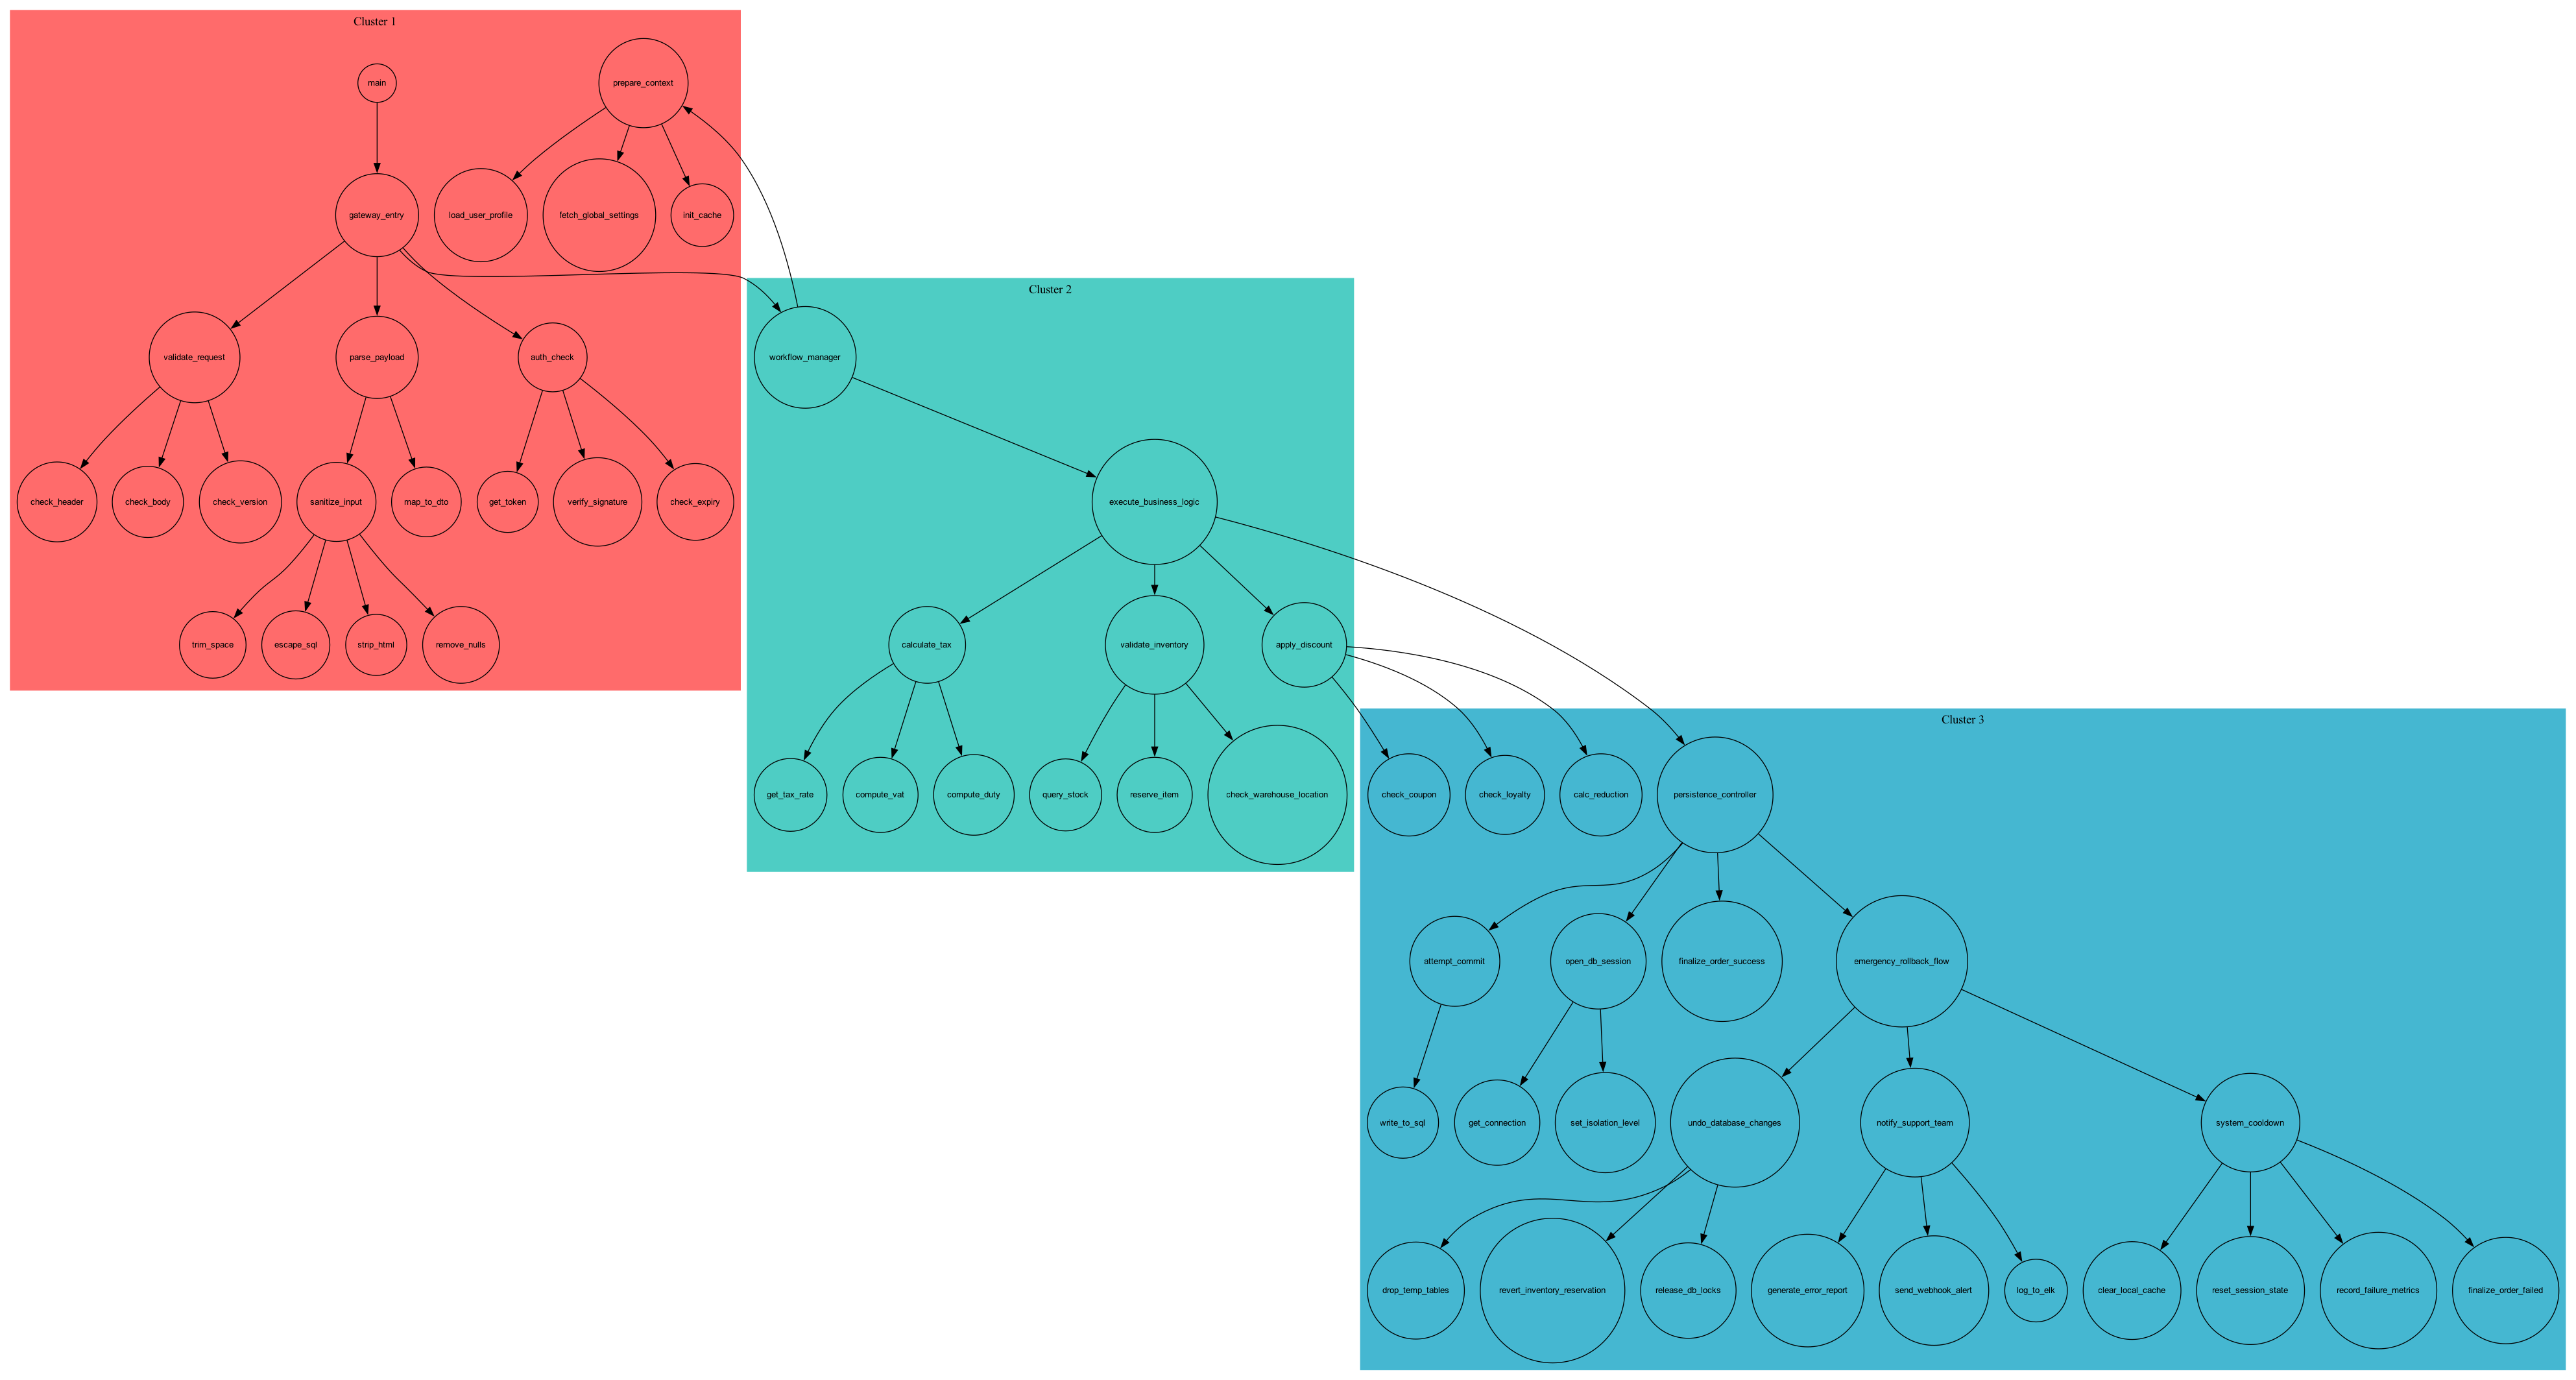


Visualisasi Summary Graph t1 (Cluster-only View)


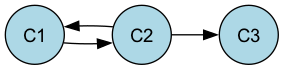

'summary_graph_t1_clusters_only.png'

In [839]:
S_t1, node_to_cluster_t1 = build_summary_graph(G_t1, clusters_t1)

print("Node to cluster mapping t1:")
print(node_to_cluster_t1)

print("\nSummary graph edges t1:")
print(list(S_t1.edges()))

print("\nVisualisasi Summary Graph t1 (Original Call Graph with Cluster Colors)")
show_graph_with_clusters(G_t1, node_to_cluster_t1, clusters_t1, "summary_graph_t1", "Call Graph with Clusters - t1")

print("\nVisualisasi Summary Graph t1 (Cluster-only View)")
show_graph(S_t1, "summary_graph_t1_clusters_only", "Summary Graph t1 (Clusters Only)")

# 24. Rekap hasil t0 vs t1

In [840]:
recap = pd.DataFrame([
    {
        "version": "t0",
        "nodes": G_t0.number_of_nodes(),
        "edges": G_t0.number_of_edges(),
        "exit_nodes": exit_t0,
        "num_paths": len(paths_t0),
        "L": L_t0,
        "clusters": clusters_t0,
        "summary_edges": list(S_t0.edges())
    },
    {
        "version": "t1",
        "nodes": G_t1.number_of_nodes(),
        "edges": G_t1.number_of_edges(),
        "exit_nodes": exit_t1,
        "num_paths": len(paths_t1),
        "L": L_t1,
        "clusters": clusters_t1,
        "summary_edges": list(S_t1.edges())
    }
])

display(recap)

,version,nodes,edges,exit_nodes,num_paths,L,clusters,summary_edges
0,t0,44,43,"[check_header, check_body, check_version, trim...",130,6,"{3: ['main', 'gateway_entry', 'validate_reques...","[(C3, C1), (C3, C2)]"
1,t1,56,55,"[check_header, check_body, check_version, trim...",187,7,"{1: ['main', 'gateway_entry', 'validate_reques...","[(C1, C2), (C2, C1), (C2, C3)]"


# 25. Optional: Jalankan pipeline sekaligus untuk satu file

Cell ini berguna nanti saat ingin menjalankan banyak test case.

In [841]:
def run_full_pipeline(file_path, k=2, label="graph"):
    G, source = extract_call_graph_from_py(file_path)

    print("="*80)
    print(f"FILE: {file_path}")
    print("="*80)

    print("\n[1] Nodes and edges")
    print("Nodes:", list(G.nodes()))
    print("Edges:", list(G.edges()))

    print("\n[2] Execution paths")
    paths = extract_execution_paths(G)
    print_paths(paths)

    print("\n[3] f(v)")
    f, L = build_path_length_profile(G, paths)
    f_norm = normalize_f_l1(f)
    display(features_to_dataframe(f, prefix="f"))
    print("L =", L)

    print("\n[4] f'(v)")
    display(features_to_dataframe(f_norm, prefix="f'"))

    print("\n[5] directed node2vec walks and e(v)")
    e, walks, model = compute_directed_node2vec_embedding(
        G,
        dimensions=EMBED_DIM,
        walk_length=WALK_LENGTH,
        num_walks=NUM_WALKS,
        p=P_RETURN,
        q=Q_INOUT,
        seed=SEED
    )
    print("Sample walks:")
    for w in walks[:5]:
        print(" -> ".join(w))
    display(features_to_dataframe(e, prefix="e"))

    print("\n[6] e'(v)")
    e_norm = normalize_e_l2(e)
    display(features_to_dataframe(e_norm, prefix="e'"))

    print("\n[7] x(v)")
    f_norm_aligned = align_feature_dimensions(f_norm, L)
    x = fuse_features(e_norm, f_norm_aligned)
    display(features_to_dataframe(x, prefix="x"))

    print("\n[8] Distance matrix")
    nodes, dist = compute_distance_matrix(x)
    display(pd.DataFrame(dist, index=nodes, columns=nodes).round(4))

    print("\n[9] Ward clustering")
    clusters, Z = ward_clustering(x, k=k)
    print_clusters(clusters)

    print("\n[10] Summary graph")
    S, node_to_cluster = build_summary_graph(G, clusters)
    print("Node to cluster:", node_to_cluster)
    print("Summary edges:", list(S.edges()))

    return {
        "G": G,
        "source": source,
        "paths": paths,
        "f": f,
        "f_norm": f_norm,
        "L": L,
        "e": e,
        "e_norm": e_norm,
        "x": x,
        "clusters": clusters,
        "summary_graph": S,
        "node_to_cluster": node_to_cluster
    }

# Contoh pemakaian:
# result_t0 = run_full_pipeline(FILE_T0, k=K_CLUSTERS, label="t0")
# result_t1 = run_full_pipeline(FILE_T1, k=K_CLUSTERS, label="t1")